# Comparativo das topologias

In [72]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
import seaborn as sns
from fnmatch import fnmatch
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [73]:
NUMBER_OF_FLOWS = 50
STEPS = 5
INTERVAL_LENGTH = int(NUMBER_OF_FLOWS / STEPS)
SESSIONS = np.arange(0, NUMBER_OF_FLOWS, step=INTERVAL_LENGTH)

In [74]:
def acceptance_rate(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    ar_result = []
    for slice in slices:
        values, counts = np.unique(slice, return_counts=True)
        if len(counts) == 1:
            if values[0] == 0:
                acc_rate = 0
            elif values[0] == 1:
                acc_rate = 1
        else:
            count_succ = counts[1]
            count_fail = counts[0]
            acc_rate = count_succ / (count_succ + count_fail)
        ar_result.append(acc_rate)
    return ar_result

In [75]:
def resource_utilization(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    resource_result = []
    for slice in slices:
        if len(slice) == 0:
            continue
        average_consumption = np.mean(slice)
        resource_result.append(average_consumption)
    return resource_result

In [76]:
# Obtenha a lista de caminhos dos arquivos CSV
topologia_1_path = glob.glob('luxembourg_4/dp_35_sfc_on_con_*/*.csv')


In [77]:
# Obtenha a lista de caminhos dos arquivos CSV
topologia_2_path = glob.glob('luxembourg_8/dp_35_sfc_on_con_*/*.csv')

In [78]:
# Obtenha a lista de caminhos dos arquivos CSV
topologia_3_path = glob.glob('luxembourg_12/dp_35_sfc_on_con_*/*.csv')

In [79]:
# Obtenha a lista de caminhos dos arquivos CSV
paloalto_path = glob.glob('paloalto/dp_35_sfc_on_con_*/*.csv')

In [231]:
ratio = []
def dataframe_dados(direc):
    df = pd.DataFrame()
    delay_df = pd.DataFrame()
    alg_name = 'dp'
    players = direc[0].split("\\")[0].split("_")[1]
    con = direc[0].split("\\")[1].split("_")[-1]
    for idx, file in enumerate(direc):
        try:

            simulation_df = pd.read_csv(file)
        except:
            continue
        #Criação de 3 colunas adicionais
        simulation_df['algorithm'] = alg_name
        simulation_df['exec'] = idx
        simulation_df['connections'] = con
        simulation_df['players'] = players
        df = pd.concat([df, simulation_df], axis=0)

    # df['dep'] = "deploy"
    # df.loc[df['sfc_id'].duplicated(keep='first'), 'dep'] = "redeploy"

    grouped_df = df.groupby(['algorithm','connections','players'])    
    
     # Contando a quantidade de "redeploy" em relação ao total
    # redeploy_count = len(df[df['dep'] == 'redeploy'])
    # total_events = len(df)
    # A relação entre redeploy e o total de eventos
    # redeploy_ratio = redeploy_count / total_events
    # ratio.append(redeploy_ratio)
    return grouped_df

In [232]:
ratio = []
grouped_flows_1 = [dataframe_dados([x]) for x in topologia_1_path]
# ratio_1 = np.mean(ratio)
# print(ratio_1)

In [233]:
ratio = []
grouped_flows_2 = [dataframe_dados([x]) for x in topologia_2_path]
ratio_2 = np.mean(ratio)

In [234]:
ratio = []
grouped_flows_3 = [dataframe_dados([x]) for x in topologia_3_path]
ratio_3 = np.mean(ratio)

In [190]:
# ratio = []
# grouped_flows_4 = [dataframe_dados([x]) for x in paloalto_path]
# ratio_4 = np.mean(ratio)
# print(ratio_4)

In [256]:
from typing import List
import numpy as np

def latency_utilization(ar_array) -> List:
    INTERVAL_LENGTH = 10  # Defina o tamanho do intervalo conforme necessário
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    resource_result = []
    
    for slice in slices:
        if len(slice) == 0:
            continue
        
        non_null_values = []
        for value in slice:
            try:
                non_null_values.append(float(value))
            except:
                print(value)
        
        print(non_null_values)
        if len(non_null_values) == 0:
            continue
        
        average_consumption = np.mean(non_null_values)
        resource_result.append(average_consumption)
    
    return resource_result

In [259]:
def format_grouped_df(grouped_df):
    acceptance_series = grouped_df['success'].apply(resource_utilization)
    bd_series = grouped_df['bandwidth_utilization'].apply(resource_utilization)
    cache_series = grouped_df['cache_utilization'].apply(resource_utilization)
    cpu_series = grouped_df['cpu_utilization'].apply(resource_utilization)
    decision_series = grouped_df['duration'].apply(resource_utilization)
    delay_series = grouped_df['latency'].apply(latency_utilization)
    # # Verifique se 'delay' não é 'None' antes de aplicar a função resource_utilization
    # delay_df = grouped_df[grouped_df['latency'] != 'None']
    # print(delay_df)
    # delay_df['latency'] = delay_df['latency'].astype(float)
    # delay_series = delay_df.groupby(['algorithm','dep','connections'])['latency'].apply(resource_utilization)

    dic = {'acceptance': acceptance_series, 'bd': bd_series, 'cpu': cpu_series, 'cache': cache_series, 'duration': decision_series,'latency':delay_series}
    return dic


In [260]:
formated_flows_1 = [format_grouped_df(x) for x in grouped_flows_1]
formated_flows_2 = [format_grouped_df(x) for x in grouped_flows_2]
formated_flows_3 = [format_grouped_df(x) for x in grouped_flows_3]
#formated_flows_4 = [format_grouped_df(x) for x in grouped_flows_4]

None
None
None
None
None
None
None
None
None
[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 4.0, 4.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 4.0, 3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 3.0, 1.0, 3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 2.0, 2.0, 2.0, 1.0, 2.0]
None
None
None
None
None
None
None
None
None
None
None
None
None
[1.0, 3.0, 2.0, 1.0, 3.0, 1.0, 3.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 1.0, 5.0, 1.0, 1.0, 1.0, 1.0, 5.0, 1.0, 1.0, 1.0, 1.0, 4.0, 5.0, 4.0, 1.0, 1.0, 1.0, 1.0, 4.0, 1.0, 1.0, 1.0, 1.0, 1.0, 6.0, 1.0, 1.0, 3.0, 3.0, 2.0, 3.0, 3.0]
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
[3.0, 3.0, 1.0, 1.0, 1.0, 4.0, 1.0, 3.0, 3.0, 3.0, 3.0, 1.0, 1.0, 1.0, 1.0, 4.

In [261]:
import pandas as pd

# Função para criar um DataFrame e listas a partir de uma lista de dicionários
def create_dataframe_and_lists(data):
    df = pd.DataFrame([x['acceptance'] for x in data]).sum()
    cpu = pd.DataFrame([x['cpu'] for x in data]).sum()
    bd = pd.DataFrame([x['bd'] for x in data]).sum()
    cache = pd.DataFrame([x['cache'] for x in data]).sum()
    decision = pd.DataFrame([x['duration'] for x in data]).sum()
    latency = pd.DataFrame([x['latency'] for x in data]).sum()
    return df, cpu, bd, cache, decision, latency

acceptance1, cpu1, bd1, cache1, decision1, latency1 = create_dataframe_and_lists(formated_flows_1)
acceptance2, cpu2, bd2, cache2, decision2,latency2 = create_dataframe_and_lists(formated_flows_2)
acceptance3, cpu3, bd3, cache3, decision3,latency3 = create_dataframe_and_lists(formated_flows_3)

acceptance = [acceptance1,acceptance2,acceptance3]
cpu = [cpu1,cpu2,cpu3]
bd = [bd1,bd2,bd3]
cache = [cache1,cache2,cache3]
decision = [decision1,decision2,decision3]
latency = [latency1,latency2,latency3]
# acceptance4 = [x['acceptance'] for x in formated_flows_4]
# cpu4 = [x['cpu'] for x in formated_flows_4]
# bd4 = [x['bd'] for x in formated_flows_4]
# cache4 = [x['cache'] for x in formated_flows_4]
# decision4 = [x['cache'] for x in formated_flows_4]

In [262]:
import plotly.io as pio
import plotly.graph_objs as go
import numpy as np

pio.kaleido.scope.chromium_args += ("--single-process",) 
colors = {'4': 'blue', '8': 'green', '12': 'orange', '6': 'red'}

def create_boxplot(resource_series_list, title, figsize=(1000, 600), xlim=None, ylim=None):
    fig = go.Figure()

    dic_else = {}

    for resource_series in resource_series_list:
        player = resource_series.index.get_level_values('players')[0]
        ar = resource_series.values.tolist()
        partitions = np.array_split(ar, len(ar))
        stacked_partitions = np.vstack(partitions)
        result = (np.sum(stacked_partitions, axis=0) / len(stacked_partitions)).ravel()
        dic_else[player] = result

    # Ordenar o dicionário pelo nome dos jogadores (chaves) em ordem crescente
    order_dic = dict(sorted(dic_else.items(), key=lambda x: int(x[0])))

    for key, data in order_dic.items():
        x_label =  key  # Adiciona o número de connections ao rótulo
        fig.add_trace(go.Box(y=data, x=[x_label] * len(data), name=key, marker=dict(color=colors[key])))

    fig.update_layout(height=figsize[1], width=figsize[0], title=title,
                      xaxis=dict(title="players"), font=dict(size=16), title_font=dict(size=20),
                      legend_font=dict(size=16), showlegend=False)
    
    if xlim is not None:
        fig.update_xaxes(range=xlim)
    if ylim is not None:
        fig.update_yaxes(range=ylim)

    fig.show()
    # Salvar o arquivo de imagem com o mesmo nome do título
    if title:
        file_name = title.lower().replace(" ", "_") + ".png"
        pio.write_image(fig, file_name, engine='kaleido')


# Acceptance

In [263]:
# Chamada para o gráfico de acceptance com xlim, ylim e figsize definidos
create_boxplot( acceptance,title='Acceptance',figsize=(600, 400))
create_boxplot( cpu,title='CPU',figsize=(600, 400))
create_boxplot( cache,title='Cache',figsize=(600, 400))
create_boxplot( bd,title='Bandwidth',figsize=(600, 400))
create_boxplot( decision,title='Decision Time',figsize=(600, 400))
create_boxplot( latency,title='Latency',figsize=(600, 400))
# create_boxplot( acceptance2,title='Acceptance - Luxembourg 2', ylim=[0.5, 1],figsize=(600, 400))
# create_boxplot( acceptance3,title='Acceptance - Luxembourg 3', ylim=[0.5, 1],figsize=(600, 400))
# create_boxplot( acceptance4,title='Acceptance - Paloalto', ylim=[0.5, 1],figsize=(600, 400))

In [265]:
from PIL import Image
import os

def combine_images(image_paths, output_path):
    # Abra as imagens especificadas na lista image_paths
    imagens = [Image.open(path) for path in image_paths]

    # Determine o tamanho da imagem final (com base na largura da primeira imagem)
    largura, altura = imagens[0].size

    # Calcule o número de linhas necessárias para ter duas imagens por linha
    num_linhas = len(imagens) // 2 + len(imagens) % 2

    # Crie uma nova imagem em branco com o tamanho desejado
    imagem_combinada = Image.new("RGB", (largura * 2, altura * num_linhas))

    # Cole as imagens na imagem combinada
    for i, imagem in enumerate(imagens):
        linha = i // 2
        coluna = i % 2
        pos_x = coluna * largura
        pos_y = linha * altura
        imagem_combinada.paste(imagem, (pos_x, pos_y))

    # Salve a imagem combinada no caminho especificado
    imagem_combinada.save(output_path)

    # Feche as imagens originais
    for imagem in imagens:
        imagem.close()

In [266]:
# Exemplo de uso:
image_paths = ["acceptance.png", "bandwidth.png", "cpu.png", "cache.png","latency.png","decision_time.png"]
combine_images(image_paths, "resultados.jpg")

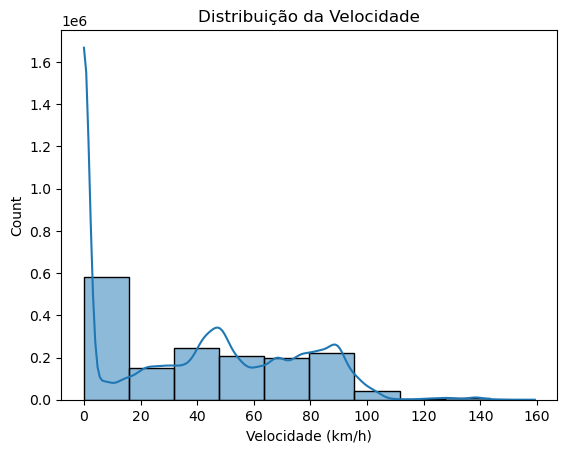

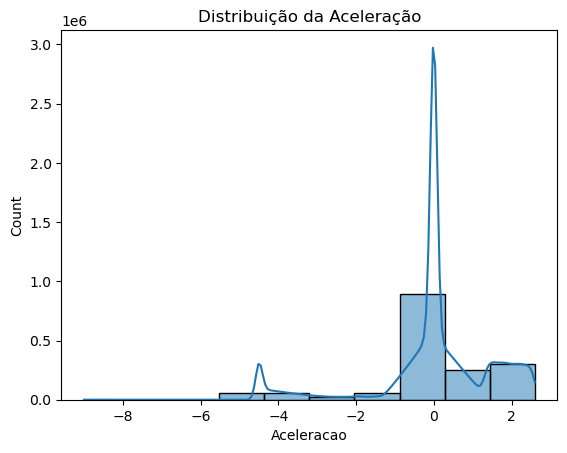

In [218]:
import pandas as pd
import matplotlib.pyplot as plt

# Ler o CSV para um DataFrame
data = pd.read_csv('dados_veiculos.csv', parse_dates=['Tempo'])
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Removendo a coluna 'Tempo'
data = data[['Velocidade (km/h)', 'Aceleracao']]

# Gráfico de dispersão (scatter plot) entre Velocidade e Aceleração
# sns.scatterplot(x='Velocidade (km/h)', y='Aceleracao', data=data)
# plt.title('Gráfico de Dispersão entre Velocidade e Aceleração')
# plt.show()

# # Gráfico de barras da média de Velocidade para cada valor de Aceleração
# sns.barplot(x='Aceleracao', y='Velocidade (km/h)', data=data, ci=None)
# plt.title('Média de Velocidade para cada Valor de Aceleração')
# plt.xticks(rotation=45)
# plt.show()

# Gráfico de distribuição (histograma) da Velocidade
sns.histplot(data=data, x='Velocidade (km/h)', bins=10, kde=True)
plt.title('Distribuição da Velocidade')
plt.show()

# Gráfico de distribuição (histograma) da Aceleração
sns.histplot(data=data, x='Aceleracao', bins=10, kde=True)
plt.title('Distribuição da Aceleração')
plt.show()
